In [45]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from model.parameters import *
from modules.transitory_functions import *

In [ ]:
Tfc = 323.15

## Stack voltage
### 1. Equilibrium potential

In [46]:
Ueq_mat = []
for C_H2_acl in np.arange(0.5, 12.5, 0.1):
    O2_axis = []
    for C_O2_ccl in np.arange(0.5, 12.5, 0.1):
        Ueq = (E0 - 8.5e-4 * (Tfc - 298.15) + R * Tfc / (2 * F) *(np.log(R * Tfc * C_H2_acl / Pref) + 0.5 * np.log(R * Tfc * C_O2_ccl / Pref)))
        O2_axis.append(Ueq)
    Ueq_mat.append(O2_axis)
Ueq_mat = np.array(Ueq_mat)

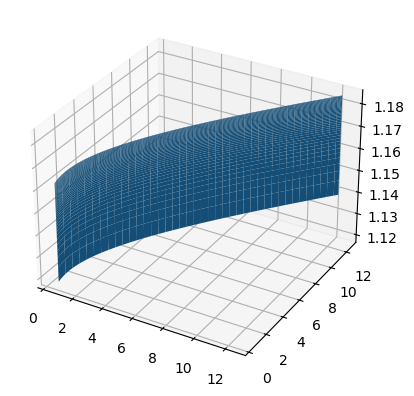

In [47]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(np.arange(0.5, 12.5, 0.1),np.arange(0.5, 12.5, 0.1), Ueq_mat)

### 2.Proton resistance

In [48]:
# The proton resistance at the membrane : Rmem
Rp_mat = []
for lambda_mem in np.arange(0.5, 12.0, 0.1):
    lambda_mem_axis = []
    for lambda_ccl in np.arange(0.5, 12.0, 0.1):
        if lambda_mem >= 1:
            Rmem = Hmem / ((0.5139 * lambda_mem - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / Tfc)))
        else:
            Rmem = Hmem / (0.1879 * np.exp(1268 * (1 / 303.15 - 1 / Tfc)))
        #  The proton resistance at the cathode catalyst layer : Rccl
        if lambda_ccl >= 1:
            Rccl = Hcl / ((epsilon_mc ** tau) * (0.5139 * lambda_ccl - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / Tfc)))
        else:
            Rccl = Hcl / ((epsilon_mc ** tau) * 0.1879 * np.exp(1268 * (1 / 303.15 - 1 / Tfc)))
        #  The total proton resistance
        Rp = Rmem + Rccl
        lambda_mem_axis.append(Rp)
    Rp_mat.append(lambda_mem_axis)
Rp_mat = np.array(Rp_mat)

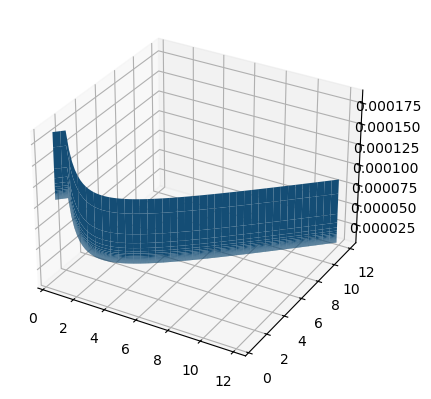

In [49]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(np.arange(0.5, 12.0, 0.1),np.arange(0.5, 12.0, 0.1), Rp_mat)

### 3. Cathode overpotential

In [51]:
Pc_des = 1.5e5
i_fc = 0.8e4
# The crossover current density
i_H2 = 2 * F * R * Tfc / Hmem * C_H2_acl * k_H2(lambda_mem, Tfc, kappa_co)
i_O2 = 4 * F * R * Tfc / Hmem * C_O2_ccl * k_O2(lambda_mem, Tfc, kappa_co)
i_n = i_H2 + i_O2
slim = a_slim * (Pc_des / 1e5) + b_slim
s_switch = a_switch * slim
f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
eta_c = 1 / f_drop * R * Tfc / (alpha_c * F) * np.log((i_fc + i_n) / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c)

In [52]:
Ucell = Ueq - (i_fc + i_n) * (Rp + Re) - eta_c